,x,std-ized
mean,2.500000,2.220446e-17
std,4.670589,1.000000e+00


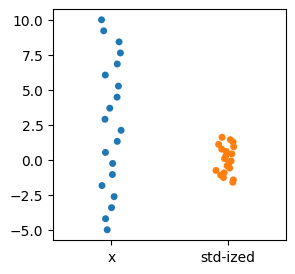

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import explained_variance_score
from sklearn.linear_model import LinearRegression
import seaborn as sns

# 1D standardization
# place evenly spaced values in a dataframe
xs = np.linspace(-5, 10, 20)
df = pd.DataFrame(xs, columns=['x'])
# center ( - mean) and scale (/ std)
df['std-ized'] = (df.x - df.x.mean()) / df.x.std()
# show original and new data; compute statistics
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
sns.stripplot(data=df)
display(df.describe().loc[['mean', 'std']])

In [ ]:
xs = np.linspace(-5, 10, 20)
ys = 3*xs + 2 + np.random.uniform(20, 40, 20)
df = pd.DataFrame({'x':xs, 'y':ys})
df_std_ized = (df - df.mean()) / df.std()
display(df_std_ized.describe().loc[['mean', 'std']])


,x,y
mean,2.220446e-17,5.995204e-16
std,1.000000e+00,1.000000e+00


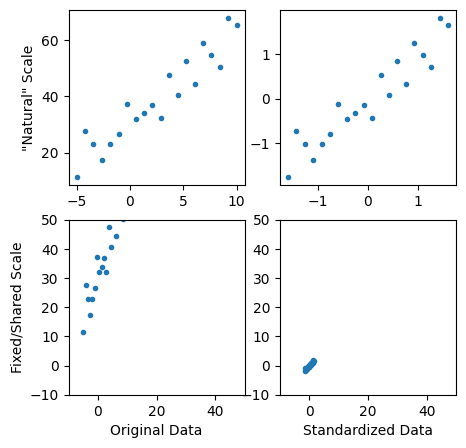

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(5, 5))
ax[0,0].plot(df.x, df.y, '.')
ax[0,1].plot(df_std_ized.x, df_std_ized.y, '.')
ax[0,0].set_ylabel('"Natural" Scale')
ax[1,0].plot(df.x, df.y, '.')
ax[1,1].plot(df_std_ized.x, df_std_ized.y, '.')
ax[1,0].axis([-10, 50, -10, 50])
ax[1,1].axis([-10, 50, -10, 50])
ax[1,0].set_ylabel('Fixed/Shared Scale')
ax[1,0].set_xlabel('Original Data')
ax[1,1].set_xlabel('Standardized Data');

In [ ]:
import sklearn.model_selection as skms
import sklearn.preprocessing as skpre

train_xs, test_xs = skms.train_test_split(xs.reshape(-1, 1), test_size=.5)
scaler = skpre.StandardScaler()
scaler.fit(train_xs).transform(test_xs)

array([[ 0.27868852],
       [-1.19672131],
       [ 1.42622951],
       [-1.03278689],
       [ 0.44262295],
       [-1.36065574],
       [-0.86885246],
       [-0.54098361],
       [ 0.60655738],
       [-0.37704918]])

In [ ]:
from sklearn import linear_model, pipeline

(train_xs, test_xs,
  train_ys, test_ys)= skms.train_test_split(xs.reshape(-1, 1),
ys.reshape(-1, 1),
  test_size=.5)
scaler = skpre.StandardScaler()
lr = linear_model.LinearRegression()
std_lr_pipe = pipeline.make_pipeline(scaler, lr)
std_lr_pipe.fit(train_xs, train_ys).predict(test_xs)

array([[29.35477373],
       [34.15404081],
       [41.35294142],
       [50.95147557],
       [19.75623959],
       [24.55550666],
       [17.35660605],
       [46.15220849],
       [60.55000972],
       [43.75257496]])